# 889. Construct Binary Tree from Preorder and Postorder Traversal

Given two integer arrays, preorder and postorder where preorder is the preorder traversal of a binary tree of distinct values and postorder is the postorder traversal of the same tree, reconstruct and return the binary tree.

If there exist multiple answers, you can return any of them.

## Example 1:

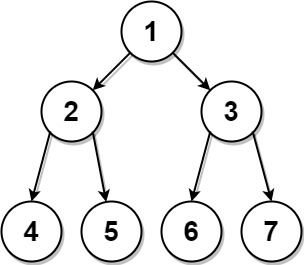

Input: preorder = [1,2,4,5,3,6,7], postorder = [4,5,2,6,7,3,1]
Output: [1,2,3,4,5,6,7]
Example 2:

## Example 2:

Constraints:

1 <= preorder.length <= 30
1 <= preorder[i] <= preorder.length
All the values of preorder are unique.
postorder.length == preorder.length
1 <= postorder[i] <= postorder.length
All the values of postorder are unique.
It is guaranteed that preorder and postorder are the preorder traversal and postorder traversal of the same binary tree.


# Specification

Reconstruir uma árvore binária a partir de preorder (root → left → right) e postorder (left → right → root), explorando o fato de que o primeiro elemento de preorder é sempre a raiz. A chave é identificar o tamanho da subárvore esquerda usando o próximo elemento do preorder dentro do postorder.

## Edge cases

- A arvore se ter 1 nó, por definição sera ela mesmo
- Arvore com apenas left ou exclusivamente right estilo uma lista encadeada
- Como os valores são únicos facilita para não lidar com duplicadas
- Se preorder e postorder os arrays terem tamanhos distintos devemos retornar None
- Se preorder ou postoder um deles forem vazios retornarmos null tambem

## Functional

```py
class Node:
    def __init__(self,val=0,left=None,right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def createTree(self, preorder: List[int], postorder: List[int])-> Optional[Node]:
        def build(preorder_start:int,preorder_end:int,postorder_star:intt,postorder_end:int)-> Optional[Node]:
            #Chamada  recursiva
            return pass # Retornar a root apos a  construção total na pilha de recursão
        return build(0,len(preorder)-1,0,len(postorder)-1) # Caso base
```

# Plan

- Divisão sucessiva usando pointeiros e usar hashmap para mapear indices do postorder
- O postorder podemos descorbir facilmente onde a Tree termina
- Usamos o preorder[0] como o caso base para nossa heuristica
- Usamos o hashmap fora da fn recursiva para mapear [valor]:indice do postorder

## Step1


preorder: node -> left -> right (top down)
postorder: left -> right -> node (bottom up)

preorder = [1,2,4,5,3,6,7], postorder = [4,5,2,6,7,3,1]
root=1,preorder[0] root=1,preorder[-1]



## Step2

- O segundo elemento o "2" no postorder marca a divisão left and right
- Ou seja [4,5,2] é left. E [6,7,3] pertence a right. O left size  aqui é 3

Left:
pre = [2,4,5] post = [4,5,2]

Right:
pre = [3,6,7] post = [6,7,3]

## Step3

Chamada recursiva

```py

# Left

build(
    preorder_start+1,
    preorder_start+left_size,
    postorder_start,
    left_root_index)

# Right

build(
    preorder_start + left_size + 1,
    preorder_end,
    left_root_index + 1,
    post_end - 1)
```


In [ ]:
# Implementação da solução
from typing import Optional

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
  
    def buildTree(self, preorder, postorder):
        postorder_index_map  = {value:i for i,value in enumerate(postorder)}
        def build(preorder_start:int,preorder_end:int,postorder_start:int,postorder_end:int)-> Optional[TreeNode]:
            if preorder_start > preorder_end:
                return None
            root = TreeNode(preorder[preorder_start])
            if preorder_start == preorder_end:
                return root

            #O prox imo el do preorder é a root da esquerda
            left_root_val = preorder_end[preorder_start + 1]

            #Vamos descobrir o indice dessa subarvore da esquerada no postorder
            left_root_index = postorder_index_map[left_root_val]

            #Descorbir o tamnho da subarvore esquerda

            left_size = left_root_index - postorder_start + 1

            root.left = build(
                        preorder_start+1,
                        preorder_start+left_size,
                        postorder_start,
                        left_root_index)
            root.right = build(
                preorder_start + left_size + 1,
                preorder_end,
                left_root_index + 1,
                postorder_end - 1
            )

            return root
        tree = build(0,len(preorder)-1,0,len(postorder)-1)
        return tree